In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv('Telecom_churn.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


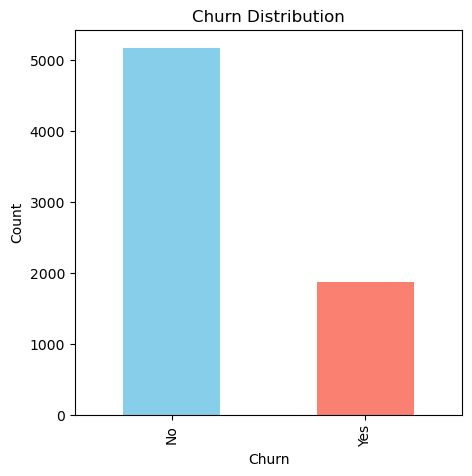

In [3]:
plt.figure(figsize=(5,5))
df['Churn'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

From the above plot , we can say that most of the customers have not switched

<Figure size 600x400 with 0 Axes>

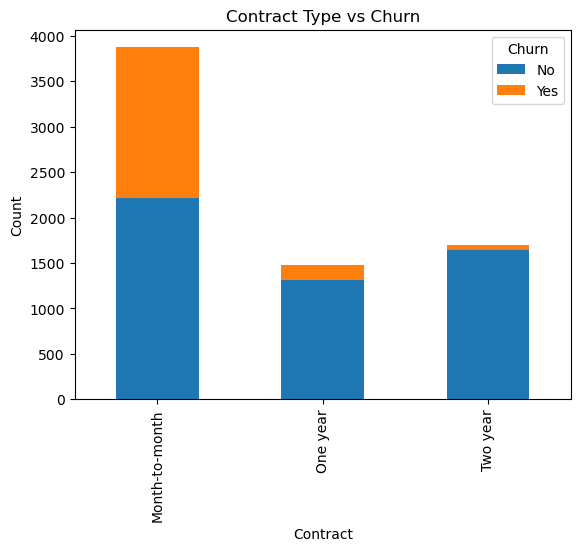

In [4]:
plt.figure(figsize=(6,4))
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar', stacked=True)
plt.title("Contract Type vs Churn")
plt.ylabel("Count")
plt.show()

From the above plot we can say that customers with month to monthcontract have the worst Churn ratio

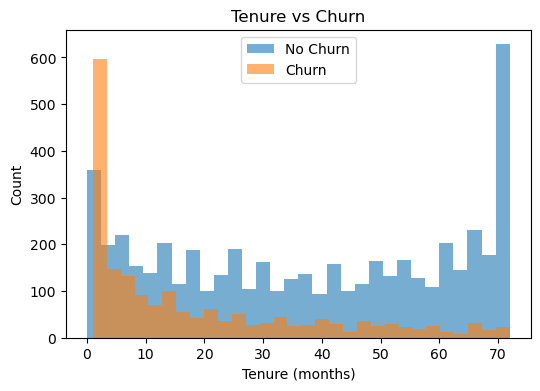

In [5]:
plt.figure(figsize=(6,4))
plt.hist(df[df['Churn']=="No"]['tenure'], bins=30, alpha=0.6, label="No Churn")
plt.hist(df[df['Churn']=="Yes"]['tenure'], bins=30, alpha=0.6, label="Churn")
plt.title("Tenure vs Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.legend()
plt.show()

Most customers who switch , switch in the first month of their tenure

In [6]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [9]:
df['Partner'].unique()

array(['Yes', 'No'], dtype=object)

In [10]:
binary_cols=['gender','Partner','Dependents','PhoneService','PaperlessBilling']
for cols in binary_cols:
    df[cols]=df[cols].map({'Male':1 , 'Female':0 , 'Yes':1 , 'No':0})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,No
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,No
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,Yes


In [11]:
df.replace([""," "],np.nan,inplace=True) 

In [12]:
multi_cat_cols = ["MultipleLines","InternetService","OnlineSecurity","OnlineBackup",
                  "DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
                  "Contract","PaymentMethod"]

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

num_cols=['tenure','MonthlyCharges','TotalCharges']
scaler = StandardScaler()

# Fit and transform
df[num_cols] = scaler.fit_transform(df[num_cols])

In [13]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,-1.277445,0,1,-1.160323,-0.994194,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,0.066327,1,0,-0.259629,-0.173740,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,-1.236724,1,1,-0.362660,-0.959649,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,0.514251,0,0,-0.746535,-0.195248,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,-1.236724,1,1,0.197365,-0.940457,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,-0.340876,1,1,0.665992,-0.129180,...,True,False,True,False,True,True,False,False,False,True
7039,2234-XADUH,0,0,1,1,1.613701,1,1,1.277533,2.241056,...,False,False,True,False,True,True,False,True,False,False
7040,4801-JZAZL,0,0,1,1,-0.870241,0,1,-1.168632,-0.854514,...,False,False,False,False,False,False,False,False,True,False
7041,8361-LTMKD,1,1,1,0,-1.155283,1,1,0.320338,-0.872095,...,False,False,False,False,False,False,False,False,False,True


In [14]:
df.isna().sum()

customerID                                0
gender                                    0
SeniorCitizen                             0
Partner                                   0
Dependents                                0
tenure                                    0
PhoneService                              0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
InternetService_Fiber optic               0
InternetService_No                        0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service          0
OnlineBackup_Yes                          0
DeviceProtection_No internet service      0
DeviceProtection_Yes                      0
TechSupport_No internet service           0
TechSupport_Yes                 

In [15]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"])
df["TotalCharges"].fillna(df.TotalCharges.median(),inplace=True)
df

C:\Users\abhin\AppData\Local\Temp\ipykernel_14688\3878545782.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df.TotalCharges.median(),inplace=True)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,-1.277445,0,1,-1.160323,-0.994194,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,0.066327,1,0,-0.259629,-0.173740,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,-1.236724,1,1,-0.362660,-0.959649,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,0.514251,0,0,-0.746535,-0.195248,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,-1.236724,1,1,0.197365,-0.940457,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,-0.340876,1,1,0.665992,-0.129180,...,True,False,True,False,True,True,False,False,False,True
7039,2234-XADUH,0,0,1,1,1.613701,1,1,1.277533,2.241056,...,False,False,True,False,True,True,False,True,False,False
7040,4801-JZAZL,0,0,1,1,-0.870241,0,1,-1.168632,-0.854514,...,False,False,False,False,False,False,False,False,True,False
7041,8361-LTMKD,1,1,1,0,-1.155283,1,1,0.320338,-0.872095,...,False,False,False,False,False,False,False,False,False,True


In [16]:
df.isna().sum()

customerID                               0
gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV

In [17]:
df['Churn']=df['Churn'].map({'Yes':1 , 'No':0})
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,-1.277445,0,1,-1.160323,-0.994194,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,0.066327,1,0,-0.259629,-0.173740,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,-1.236724,1,1,-0.362660,-0.959649,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,0.514251,0,0,-0.746535,-0.195248,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,-1.236724,1,1,0.197365,-0.940457,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,-0.340876,1,1,0.665992,-0.129180,...,True,False,True,False,True,True,False,False,False,True
7039,2234-XADUH,0,0,1,1,1.613701,1,1,1.277533,2.241056,...,False,False,True,False,True,True,False,True,False,False
7040,4801-JZAZL,0,0,1,1,-0.870241,0,1,-1.168632,-0.854514,...,False,False,False,False,False,False,False,False,True,False
7041,8361-LTMKD,1,1,1,0,-1.155283,1,1,0.320338,-0.872095,...,False,False,False,False,False,False,False,False,False,True


In [18]:
df1=df.drop(columns=['Churn','customerID'])
df2=df['Churn']

In [19]:
df1

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.994194,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.066327,1,0,-0.259629,-0.173740,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.959649,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.514251,0,0,-0.746535,-0.195248,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.236724,1,1,0.197365,-0.940457,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,-0.340876,1,1,0.665992,-0.129180,False,...,True,False,True,False,True,True,False,False,False,True
7039,0,0,1,1,1.613701,1,1,1.277533,2.241056,False,...,False,False,True,False,True,True,False,True,False,False
7040,0,0,1,1,-0.870241,0,1,-1.168632,-0.854514,True,...,False,False,False,False,False,False,False,False,True,False
7041,1,1,1,0,-1.155283,1,1,0.320338,-0.872095,False,...,False,False,False,False,False,False,False,False,False,True


In [28]:
df1.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                   float64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes     

In [20]:
df2

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [30]:
X_train,X_test,y_train,y_test=train_test_split(df1,df2,test_size=0.2)

Logistic Regression

In [22]:
reg=LogisticRegression()
reg.fit(X_train,y_train)

LogisticRegression()

In [23]:
from sklearn.model_selection import cross_val_score
cross_val_score(reg,X_train,y_train)

array([0.79769299, 0.80035492, 0.80212955, 0.79946761, 0.80994671])

In [24]:
y_pred=reg.predict(X_test)
y_pred
y_prob=reg.predict_proba(X_test)[:,1]

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix
result1={'Model':'Logistic Regression',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

<Axes: >

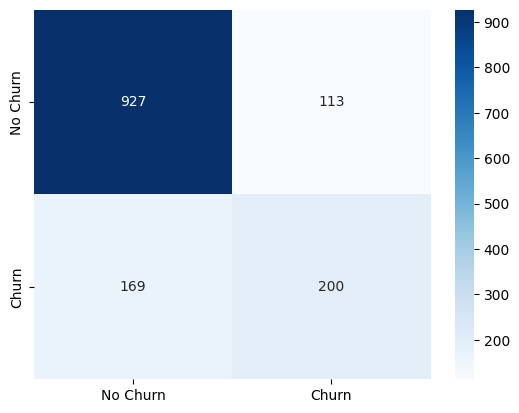

In [28]:
cm=confusion_matrix(y_test,y_pred)
labels = ["No Churn", "Churn"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

Random Forest

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']  
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring='f1',
    cv=3,        
    n_jobs=1,    
    verbose=1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
print("Best RF Params:", rf_grid.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best RF Params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [33]:
model1=RandomForestClassifier(class_weight='balanced', max_depth= 10, min_samples_leaf= 1, min_samples_split= 2, n_estimators= 200)
model1.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200)

In [34]:
cross_val_score(model1,X_train,y_train)

array([0.78438332, 0.77728483, 0.77018634, 0.78793256, 0.78063943])

In [35]:
y_pred=model1.predict(X_test)
y_pred
y_prob=model1.predict_proba(X_test)[:,1]

In [36]:
result2={'Model':'Random Forest',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

<Axes: >

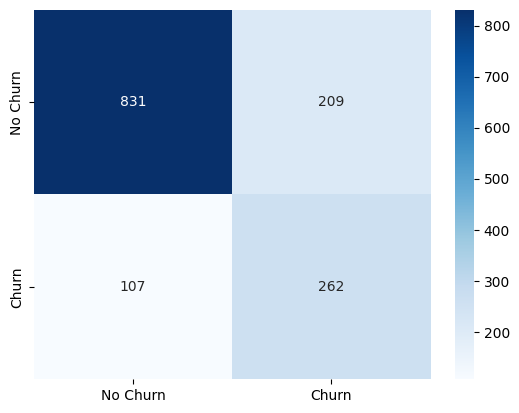

In [37]:
cm=confusion_matrix(y_test,y_pred)
labels = ["No Churn", "Churn"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

Support Vector Machine

In [39]:
from sklearn.svm import SVC
svm = SVC(random_state=42)

# Optimized small parameter grid
svm_param_grid = {
    'C': [0.1, 1, 10],            # Regularization parameter
    'kernel': ['linear', 'rbf'],  # Choose 1-2 kernels for testing
    'gamma': ['scale', 'auto']    # Only relevant for 'rbf' kernel
}

# GridSearchCV
svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_param_grid,
    scoring='f1',
    cv=3,        # fewer folds for faster execution
    n_jobs=1,    # avoid freezing CPU
    verbose=1
)

# Fit the model
svm_grid.fit(X_train, y_train)

# Best estimator and params
best_svm = svm_grid.best_estimator_
print("Best SVM Params:", svm_grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best SVM Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [40]:
model=SVC(probability=True,C=1,kernel='linear',gamma='scale')
model.fit(X_train,y_train)

SVC(C=1, kernel='linear', probability=True)

In [41]:
cross_val_score(model,X_train,y_train)

array([0.79591837, 0.80834073, 0.79325643, 0.79148181, 0.80106572])

In [42]:
y_pred=model.predict(X_test)
y_pred
y_prob=model.predict_proba(X_test)[:,1]

In [43]:
result3={ 'Model': 'SVM',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)    
    }

<Axes: >

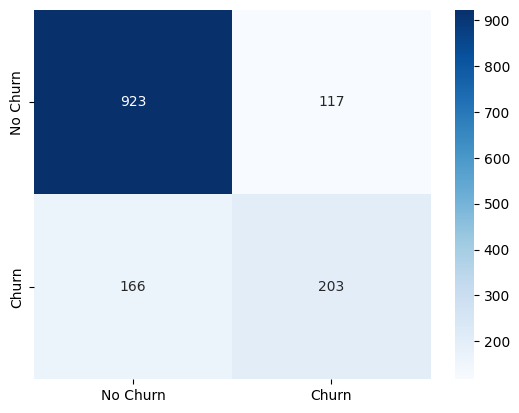

In [44]:
cm=confusion_matrix(y_test,y_pred)
labels = ["No Churn", "Churn"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

In [45]:
final_results=[]
final_results.append(result1)
final_results.append(result2)
final_results.append(result3)

In [46]:
comparison=pd.DataFrame(final_results)
comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.799858,0.638978,0.542005,0.58651,0.846292
1,Random Forest,0.775727,0.556263,0.710027,0.62381,0.847089
2,SVM,0.799148,0.634375,0.550136,0.58926,0.827905


In [31]:
import tensorflow as tf
from tensorflow import keras


model = keras.Sequential([
    keras.layers.Dense(30, input_shape=(30,), activation='relu'),
    keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# opt = keras.optimizers.Adam(learning_rate=0.01)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10)

Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7756 - loss: 0.4776
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7922 - loss: 0.4307
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7952 - loss: 0.4209
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8014 - loss: 0.4169
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8009 - loss: 0.4139
Epoch 6/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8012 - loss: 0.4116
Epoch 7/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8058 - loss: 0.4106
Epoch 8/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8037 - loss: 0.4098
Epoch 9/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8056 - loss: 0.4077
Epoch 10/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8094 - loss: 0.4065


In [33]:
yp = model.predict(X_test)
y_pred = []
for element in yp:
    if element > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [34]:
from sklearn.metrics import confusion_matrix , classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1055
           1       0.66      0.53      0.59       354

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.81      1409

